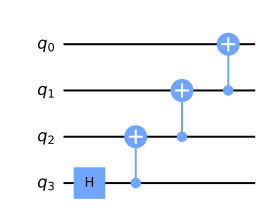

In [3]:
from qiskit import QuantumCircuit

qc = QuantumCircuit(4)
qc.h(3)
qc.cx(3, 2)
qc.cx(2, 1)
qc.cx(1, 0)
qc.draw('mpl', filename='quantum_circuit.png')

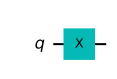

In [2]:
from qiskit import QuantumCircuit

qc = QuantumCircuit(1)
qc.x(0)
qc.draw('mpl', filename='x.png')

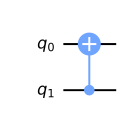

In [1]:
from qiskit import QuantumCircuit

qc = QuantumCircuit(2)
qc.cx(1, 0)
qc.draw('mpl', filename='cx.png')

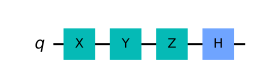

In [4]:
from qiskit import QuantumCircuit

qc = QuantumCircuit(1)
qc.x(0)
qc.y(0)
qc.z(0)
qc.h(0)
qc.draw('mpl', filename='xyzh.png')

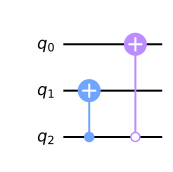

In [2]:
from qiskit import QuantumCircuit

qc = QuantumCircuit(3)
qc.cx(2, 1)
qc.cx(2, 0, ctrl_state=0)
qc.draw('mpl', filename='cx0.png')

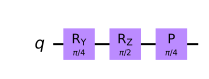

In [6]:
from qiskit import QuantumCircuit
import math

qc = QuantumCircuit(1)
qc.ry(math.pi/4, 0)
qc.rz(math.pi/2, 0)
qc.p(math.pi/4, 0)
qc.draw('mpl', filename='ry-rz-p.png')

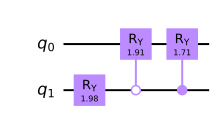

In [7]:
from qiskit import QuantumCircuit
import math

th0 = 2*math.atan2(math.sqrt(7), math.sqrt(3))
th10 = 2*math.atan2(math.sqrt(2), math.sqrt(1))
th11 = 2*math.atan2(math.sqrt(4), math.sqrt(3))

qc = QuantumCircuit(2)
qc.ry(th0, 1)
qc.cry(th10, 1, 0, ctrl_state='0')
qc.cry(th11, 1, 0)
qc.draw('mpl', filename='embed_example_circuit.png')

In [8]:
from qiskit import transpile
from qiskit.circuit import QuantumCircuit
from qiskit.visualization import plot_histogram
from qiskit_aer import Aer, AerSimulator
import math

th0 = 2*math.atan2(math.sqrt(7), math.sqrt(3))
th10 = 2*math.atan2(math.sqrt(2), math.sqrt(1))
th11 = 2*math.atan2(math.sqrt(4), math.sqrt(3))

qc = QuantumCircuit(2,2)
qc.ry(th0, 1)
qc.cry(th10, 1, 0, ctrl_state='0')
qc.cry(th11, 1, 0)
qc.measure([0,1], [0,1])
qc.draw('mpl', filename='embed_example_circuit_with_measure.png')

backend = Aer.get_backend('aer_simulator')
transpiled_qc = transpile(qc, backend)
result = backend.run(transpiled_qc, shots=1000).result()
counts = result.get_counts()
plot_histogram(counts, filename='embed_example_histogram.png')


In [ ]:
from qiskit import transpile
from qiskit.circuit import QuantumCircuit
from qiskit.visualization import plot_histogram
from qiskit_aer import Aer, AerSimulator
import math

th0 = 2*math.atan2(math.sqrt(7), math.sqrt(3))
th10 = 2*math.atan2(math.sqrt(2), math.sqrt(1))
th11 = 2*math.atan2(math.sqrt(4), math.sqrt(3))

qc = QuantumCircuit(2)
qc.ry(th0, 1)
qc.cry(th10, 1, 0, ctrl_state='0')
qc.cry(th11, 1, 0)
qc.save_statevector("sv")
qc.draw('mpl', filename='embed_example_circuit_with_measure.png')

backend = Aer.get_backend('aer_simulator')
transpiled_qc = transpile(qc, backend)
result = backend.run(transpiled_qc, shots=1000).result()
sv = result.data()['sv']
for i in range(len(sv)):
    print(f"sv[{i:02b}] = {sv[i]:f}, abs**2 = {abs(sv[i])**2:f}")

sv[00] = 0.316228+0.000000j, abs = 0.100000
sv[01] = 0.447214+0.000000j, abs = 0.200000
sv[10] = 0.547723+0.000000j, abs = 0.300000
sv[11] = 0.632456+0.000000j, abs = 0.400000


/tmp/ipykernel_12673/3542604808.py:22: DeprecationWarning: The return type of saved statevectors has been changed from a `numpy.ndarray` to a `qiskit.quantum_info.Statevector` as of qiskit-aer 0.10. Accessing numpy array attributes is deprecated and will result in an error in a future release. To continue using saved result objects as arrays you can explicitly cast them using  `np.asarray(object)`.
  for i in range(len(sv)):


## cocary

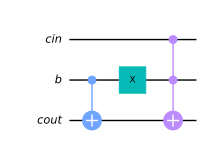

In [10]:
from qiskit import QuantumCircuit, QuantumRegister
import crsq_arithmetic.bit_ops as bb
import matplotlib.pyplot as plt

cin = QuantumRegister(1, "cin")  # carry in
b = QuantumRegister(1, "b")
cout = QuantumRegister(1, "cout")
qc = QuantumCircuit(cin, b, cout)
y=1
# hide internals
# qc.append(bb.cocarry_gate(y), [cin, b, cout])
# qc.barrier()
# show internals
bb.cocarry(qc, cin, y, b, cout)

fig,ax = plt.subplots(figsize=(3,2), layout='constrained')
filename='cocarry_diagram.png'
qc.draw(ax = ax)
fig.savefig(filename)


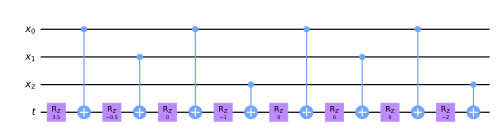

In [11]:
from crsq.blocks.gray_code_qrom import GrayCodeQrom
import numpy

alpha = numpy.array([0,1,2,3,4,5,6,7])

circ = GrayCodeQrom(3, alpha)

circ.circuit.draw(filename="ucrz-n3.png", scale=0.6)

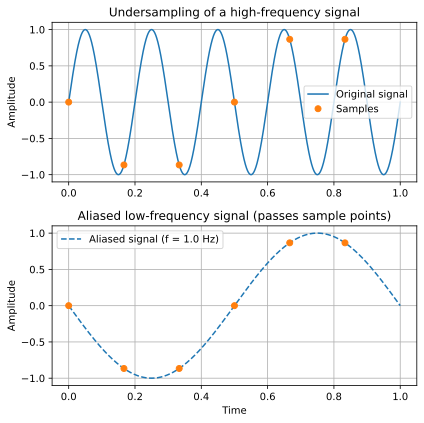

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ===== 設定 =====
f_signal = 5.0      # 元の信号周波数
f_sample = 6.0      # サンプリング周波数（ナイキスト未満）

t_cont = np.linspace(0, 1, 2000)
t_sample = np.arange(0, 1, 1 / f_sample)

# ===== 元の信号 =====
x_cont = np.sin(2 * np.pi * f_signal * t_cont)
x_sample = np.sin(2 * np.pi * f_signal * t_sample)

# ===== エイリアス周波数 =====
n = round(f_signal / f_sample)
f_alias = abs(f_signal - n * f_sample)

# サンプル点を通るように位相を合わせる
phi = 2 * np.pi * (f_signal - f_alias) * t_sample[0]
x_alias = -np.sin(2 * np.pi * f_alias * t_cont + phi)

# ===== 描画 =====
plt.figure(figsize=(6, 6))

# 上段
plt.subplot(2, 1, 1)
plt.plot(t_cont, x_cont, label="Original signal")
plt.plot(t_sample, x_sample, 'o', label="Samples")
plt.title("Undersampling of a high-frequency signal")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True)

# 下段
plt.subplot(2, 1, 2)
plt.plot(t_cont, x_alias, '--', label=f"Aliased signal (f = {f_alias:.1f} Hz)")
plt.plot(t_sample, x_sample, 'o')
plt.title("Aliased low-frequency signal (passes sample points)")
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True)

plt.tight_layout()
#plt.show()
plt.savefig('output/diagrams/aliasing_example.png')


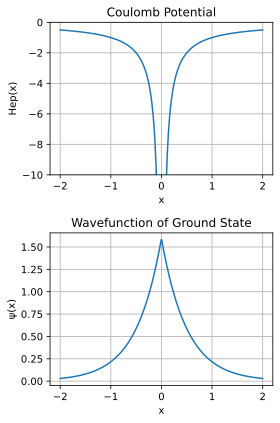

In [12]:
import matplotlib.pyplot as plt
import numpy as np
import math

x = np.linspace(-2, 2, 400)
v = -1 / np.abs(x)
psi = math.sqrt(8/math.pi)*np.exp(-2*np.abs(x))

fig, axs = plt.subplots(2, 1, figsize=(4, 6))
ax = axs[0]
ax.plot(x,v)
ax.set_title('Coulomb Potential')
ax.set_xlabel('x')
ax.set_ylabel('Hep(x)')
ax.set_ylim(-10, 0)
ax.grid()

ax = axs[1]
ax.plot(x,psi)
ax.set_title('Wavefunction of Ground State')
ax.set_xlabel('x')
ax.set_ylabel('ψ(x)')
ax.grid()
fig.tight_layout()
fig.savefig('output/diagrams/coulomb_potential_wavefunction.png')



In [1]:
import matplotlib.pyplot as plt
import numpy as np

def psi0_0(x):
    return np.sqrt(8/np.pi)*np.exp(-2*np.abs(x))

def psi1_0(x):
    return np.sqrt(8/(27*np.pi))*(1-4*np.abs(x)/3)*np.exp(-2*np.abs(x)/3)

def psi1_1(x):
    return 8/(9*np.sqrt(3*np.pi))*np.abs(x)*np.exp(-2*np.abs(x)/3)

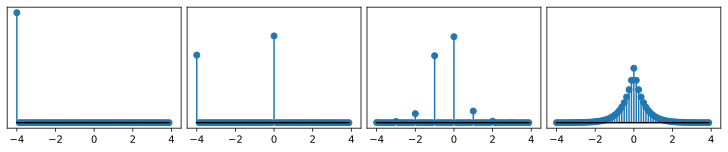

In [2]:
# fig, axs = plt.subplots(1,4, figsize=(6,2.5))
n = 6
N= 2**n
HN = N/2
L=8
dx = L/N
x = np.linspace(-L/2, L/2 - dx, N)
psi = np.zeros((n+1, N), dtype=float)

psi[0,:] = psi0_0(x)*np.sqrt(L/N)
for s in range(0, n):
    hst = 1<<s
    st = hst<<1
    for j in range(0,N,st):
        psi[s+1,j] = np.sqrt(psi[s, j]**2 + psi[s, j+hst]**2)

fig, axs = plt.subplots(1,4, figsize=(10,2), sharey=True, constrained_layout=True)
idx = [0, 1, 3, 6]
for i in range(4):
    ax = axs[i]
    ax.stem(x, psi[n-idx[i],:], linefmt='C0-', markerfmt='C0o', basefmt='k-')
    #ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlim(-L/2-dx*4, L/2 + dx*4)

fig.savefig('output/diagrams/amplitude_distribution.png')

# conceptual diagram of the Slater determinant

/tmp/ipykernel_48164/105699466.py:28: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


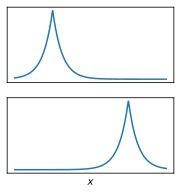

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import cmasher as cmr

x = np.linspace(0, 8, 400)
def psi01(x):
    return psi0_0(x-2)

def psi02(x):
    return psi0_0(x-6)

fig, axs = plt.subplots(2,1, figsize=(3,3))
ax = axs[0]
ax.plot(x, psi01(x), label=r'$\psi_1(x)$')
ax.set_xticks([])
ax.set_yticks([])
# ax.set_ylabel('$\psi_1(x)$')

ax = axs[1]
ax.plot(x, psi02(x), label=r'$\psi_2(x)$')
ax.set_xlabel('$x$')
ax.set_xticks([])
ax.set_yticks([])
# ax.set_ylabel('$\psi_2(x)$')
# ax.set_title('Wavefunctions of Two Localized States')
# ax.legend()
fig.savefig('output/diagrams/localized_wavefunctions_0_0.png')
fig.show()

/tmp/ipykernel_48164/2937873342.py:26: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


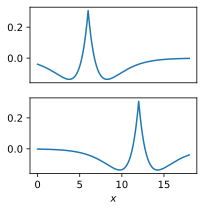

In [4]:
x = np.linspace(0, 18, 400)

def psi11(x):
    return psi1_0(x-6)

def psi12(x):
    return psi1_0(x-12)

x = np.linspace(0, 18, 400)
fig, axs = plt.subplots(2,1, figsize=(3,3))
ax = axs[0]
ax.plot(x, psi11(x), label=r'$\psi_1(x)$')
ax.set_xticks([])
# ax.set_yticks([])
# ax.set_ylabel('$\psi_1(x)$')

ax = axs[1]
ax.plot(x, psi12(x), label=r'$\psi_2(x)$')
ax.set_xlabel('$x$')
# ax.set_xticks()
# ax.set_yticks([])
# ax.set_ylabel('$\psi_2(x)$')
# ax.set_title('Wavefunctions of Two Localized States')
# ax.legend()
fig.savefig('output/diagrams/localized_wavefunctions_1_0.png')
fig.show()

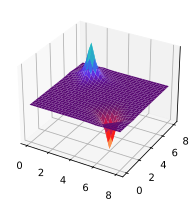

In [31]:
def Psi0(x1,x2):
    return (psi01(x1)*psi02(x2) - psi01(x2)*psi02(x1))/np.sqrt(2)

cmap = plt.get_cmap('cmr.guppy')

fig = plt.figure(figsize=(3,3), layout='tight')
ax = fig.add_subplot(111, projection='3d')
N=32
X1 = np.linspace(0, 8, N)
X2 = np.linspace(0, 8, N)
X1, X2 = np.meshgrid(X1, X2)
Z = Psi0(X1, X2)
ax.plot_surface(X1, X2, Z, cmap=cmap)
# ax.set_xlabel('$x_1$')
# ax.set_xticks([])
# ax.set_ylabel('$x_2$')
# ax.set_yticks([])
# ax.set_title(r'$\Psi(x_1, x_2)$')
ax.set_zticks([])
# ax.set_title('Two-Electron Antisymmetric Wavefunction')
# fig.patch.set_alpha(0)
fig.savefig('output/diagrams/two_electron_wavefunction_0_0.png', transparent=True)


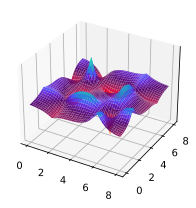

In [30]:
def psi01(x):
    return psi0_0(x-2)

def psi02(x):
    return psi0_0(x-6)

def psi11(x):
    return psi1_0(x-2)

def psi12(x):
    return psi1_0(x-6)

def Psi0(x1, x2):
    return (psi01(x1)*psi02(x2) - psi01(x2)*psi02(x1))/np.sqrt(2)

def Psi1(x1, x2):
    return (psi11(x1)*psi12(x2) - psi11(x2)*psi12(x1))/np.sqrt(2)

fig = plt.figure(figsize=(3,3), layout='tight')
ax = fig.add_subplot(111, projection='3d')
N=256
X1 = np.linspace(0, 8, N)
X2 = np.linspace(0, 8, N)
X1, X2 = np.meshgrid(X1, X2)
Z = Psi1(X1, X2)
ax.plot_surface(X1, X2, Z, cmap=cmap)
ax.set_zlim(-0.1,0.1)
# ax.set_xlabel('$x_1$')
# ax.set_xticks([])
# ax.set_ylabel('$x_2$')
# ax.set_yticks([])
# ax.set_title(r'$\Psi(x_1, x_2)$')
ax.set_zticks([])
# ax.set_title('Two-Electron Antisymmetric Wavefunction')
# fig.patch.set_alpha(0)
fig.savefig('output/diagrams/two_electron_wavefunction_1_0.png', transparent=True)
